In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
print("done")

done


In [10]:
DATASET_PATH = r"F:\SIH2025\dataset\Indian_bovine_breeds"

print(f"\n🔍 Exploring dataset at: {DATASET_PATH}")
print("="*60)

# Check if dataset path exists
if not os.path.exists(DATASET_PATH):
    print(f"❌ ERROR: Dataset path not found!")
    print(f"Please check: {DATASET_PATH}")
else:
    print(f"✅ Dataset path found!")


🔍 Exploring dataset at: F:\SIH2025\dataset\Indian_bovine_breeds
✅ Dataset path found!


In [12]:
# List all breed folders
breed_folders = [f for f in os.listdir(DATASET_PATH) 
                    if os.path.isdir(os.path.join(DATASET_PATH, f))]
    
print(f"\n📁 Found {len(breed_folders)} breed folders:")


📁 Found 41 breed folders:


In [16]:
breed_stats = {}
total_images = 0
    
for breed in sorted(breed_folders):
        breed_path = os.path.join(DATASET_PATH, breed)
        # Count images in each breed folder
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_count = 0
        
        for file in os.listdir(breed_path):
            if any(file.lower().endswith(ext) for ext in image_extensions):
                image_count += 1
        
        breed_stats[breed] = image_count
        total_images += image_count
        
        print(f"   {breed:20} - {image_count:3d} images")
    
print(f"\n📊 DATASET SUMMARY:")
print(f"   Total Breeds: {len(breed_folders)}")
print(f"   Total Images: {total_images}")
print(f"   Average per breed: {total_images//len(breed_folders) if breed_folders else 0}")
    

   Alambadi             -  99 images
   Amritmahal           -  94 images
   Ayrshire             - 234 images
   Banni                - 108 images
   Bargur               -  93 images
   Bhadawari            -  86 images
   Brown_Swiss          - 225 images
   Dangi                -  82 images
   Deoni                -  99 images
   Gir                  - 372 images
   Guernsey             - 119 images
   Hallikar             - 186 images
   Hariana              - 129 images
   Holstein_Friesian    - 328 images
   Jaffrabadi           - 101 images
   Jersey               - 203 images
   Kangayam             -  91 images
   Kankrej              - 178 images
   Kasargod             -  95 images
   Kenkatha             -  55 images
   Kherigarh            -  36 images
   Khillari             - 113 images
   Krishna_Valley       - 136 images
   Malnad_gidda         - 107 images
   Mehsana              -  94 images
   Murrah               - 173 images
   Nagori               -  88 images
 

In [17]:
# Identify breeds with sufficient images for testing
min_images_needed = 15  # Minimum for meaningful train/test split
good_breeds = {breed: count for breed, count in breed_stats.items() 
                   if count >= min_images_needed}
    
print(f"\n🎯 Breeds suitable for testing (≥{min_images_needed} images):")
for breed, count in sorted(good_breeds.items(), key=lambda x: x[1], reverse=True):
        print(f"   {breed:20} - {count:3d} images")


🎯 Breeds suitable for testing (≥15 images):
   Sahiwal              - 439 images
   Gir                  - 372 images
   Holstein_Friesian    - 328 images
   Ayrshire             - 234 images
   Brown_Swiss          - 225 images
   Tharparkar           - 217 images
   Jersey               - 203 images
   Ongole               - 191 images
   Hallikar             - 186 images
   Nagpuri              - 182 images
   Kankrej              - 178 images
   Murrah               - 173 images
   Red_Dane             - 167 images
   Red_Sindhi           - 162 images
   Rathi                - 149 images
   Vechur               - 140 images
   Krishna_Valley       - 136 images
   Hariana              - 129 images
   Pulikulam            - 124 images
   Toda                 - 124 images
   Guernsey             - 119 images
   Khillari             - 113 images
   Banni                - 108 images
   Malnad_gidda         - 107 images
   Jaffrabadi           - 101 images
   Alambadi             -  99 

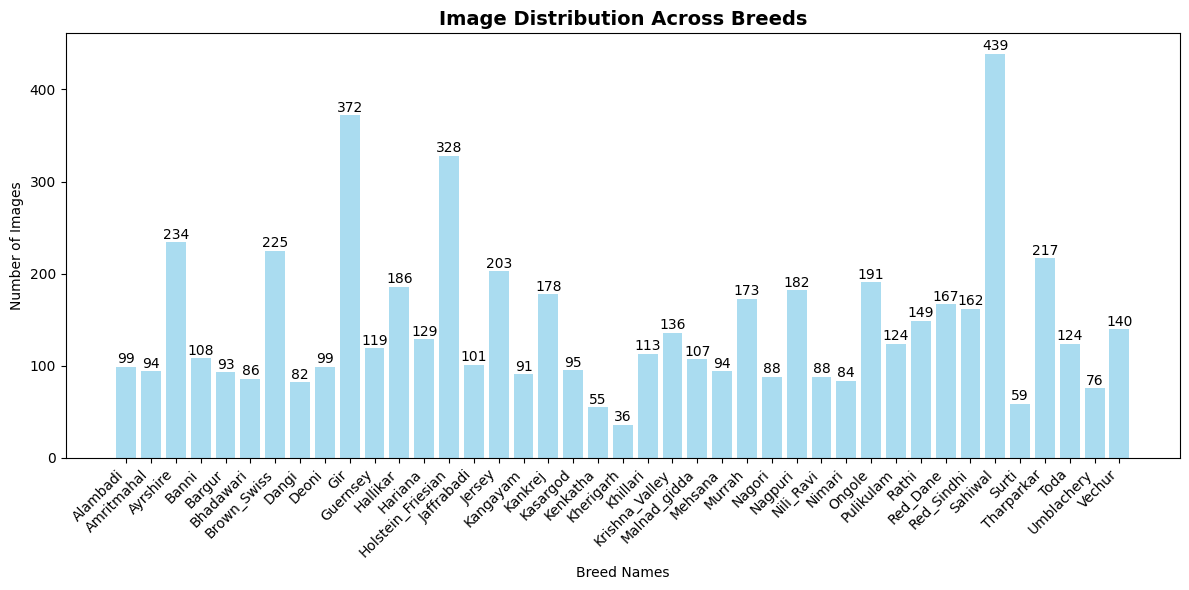


🖼️  SAMPLE IMAGES PREVIEW (Top 5 Breeds):


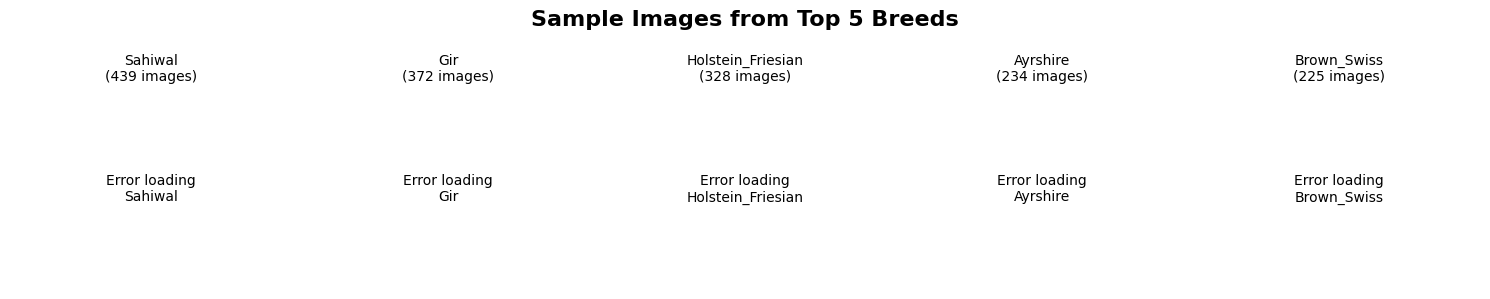


🎯 RECOMMENDED BREEDS FOR INITIAL TESTING:
✅ Perfect! You have 5+ breeds with good image counts:
   1. Sahiwal              - 439 images
   2. Gir                  - 372 images
   3. Holstein_Friesian    - 328 images
   4. Ayrshire             - 234 images
   5. Brown_Swiss          - 225 images

💡 SUGGESTED 5-BREED STARTER SET:
   Sahiwal, Gir, Holstein_Friesian, Ayrshire, Brown_Swiss

✅ STEP 1 COMPLETE!
Next steps:
1. ✅ Dataset explored and validated
2. 🔄 Ready to select subset for training
3. 🔄 Ready to start algorithm testing


In [25]:
# Visualize breed distribution
plt.figure(figsize=(12, 6))
breeds = list(breed_stats.keys())
counts = list(breed_stats.values())
    
plt.bar(breeds, counts, color='skyblue', alpha=0.7)
plt.title('Image Distribution Across Breeds', fontsize=14, fontweight='bold')
plt.xlabel('Breed Names')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
    
# Add value labels on bars
for i, v in enumerate(counts):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    
plt.tight_layout()
plt.show()
    
# Sample images preview (Top 5 breeds only)
print(f"\n🖼️  SAMPLE IMAGES PREVIEW (Top 5 Breeds):")
print("="*50)
    
# Select top 5 breeds with most images for preview
top_5_breeds = sorted(good_breeds.items(), key=lambda x: x[1], reverse=True)[:5]
    
if len(top_5_breeds) > 0:
    fig, axes = plt.subplots(1, len(top_5_breeds), figsize=(15, 3))
    fig.suptitle('Sample Images from Top 5 Breeds', fontsize=16, fontweight='bold')
        
    # Handle case where we have only 1 breed
    if len(top_5_breeds) == 1:
        axes = [axes]
        
    for idx, (breed, count) in enumerate(top_5_breeds):
        breed_path = os.path.join(DATASET_PATH, breed)
            
        # Get first image from this breed
        image_files = [f for f in os.listdir(breed_path) 
                       if any(f.lower().endswith(ext) for ext in image_extensions)]
            
        if image_files:
            sample_image_path = os.path.join(breed_path, image_files[0])
                
            try:
                # Load image using our helper function
                img_rgb = load_image(sample_image_path)
                    
                if img_rgb is not None:
                    axes[idx].imshow(img_rgb)
                    axes[idx].set_title(f"{breed}\n({count} images)", fontsize=10)
                    axes[idx].axis('off')
                else:
                    raise Exception("Failed to load image")
                    
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error loading\n{breed}', 
                               ha='center', va='center', transform=axes[idx].transAxes)
                axes[idx].set_title(f"{breed}\n({count} images)", fontsize=10)
                axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("❌ No breeds with sufficient images found for preview")
    
# Recommend best breeds for initial testing
print(f"\n🎯 RECOMMENDED BREEDS FOR INITIAL TESTING:")
print("="*50)
    
if len(top_5_breeds) >= 5:
    print("✅ Perfect! You have 5+ breeds with good image counts:")
    for i, (breed, count) in enumerate(top_5_breeds[:5], 1):
        print(f"   {i}. {breed:20} - {count:3d} images")
        
    print("\n💡 SUGGESTED 5-BREED STARTER SET:")
    starter_breeds = [breed for breed, count in top_5_breeds[:5]]
    print("   " + ", ".join(starter_breeds))
        
else:
    print(f"⚠️  Only {len(top_5_breeds)} breeds have sufficient images (≥{min_images_needed})")
    print("Consider reducing minimum images per breed or adding more data")
        
    for i, (breed, count) in enumerate(top_5_breeds, 1):
        print(f"   {i}. {breed:20} - {count:3d} images")

print(f"\n✅ STEP 1 COMPLETE!")
print("="*50)
print("Next steps:")
print("1. ✅ Dataset explored and validated")
print("2. 🔄 Ready to select subset for training")
print("3. 🔄 Ready to start algorithm testing")
print("="*50)
